<h1> Introduction to wrapper methods</h1>

In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import matplotlib.pyplot as plt
  
# fetch dataset 
breast_cancer_coimbra = fetch_ucirepo(id=451) 
  
# data (as pandas dataframes) 
X = breast_cancer_coimbra.data.features 
y = breast_cancer_coimbra.data.targets 
health = pd.concat([X,y], axis=1)
print(health.head())
  
# variable information 
print(breast_cancer_coimbra.variables) 

   Age        BMI  Glucose  Insulin      HOMA   Leptin  Adiponectin  Resistin  \
0   48  23.500000       70    2.707  0.467409   8.8071     9.702400   7.99585   
1   83  20.690495       92    3.115  0.706897   8.8438     5.429285   4.06405   
2   82  23.124670       91    4.498  1.009651  17.9393    22.432040   9.27715   
3   68  21.367521       77    3.226  0.612725   9.8827     7.169560  12.76600   
4   86  21.111111       92    3.549  0.805386   6.6994     4.819240  10.57635   

     MCP.1  Classification  
0  417.114               1  
1  468.786               1  
2  554.697               1  
3  928.220               1  
4  773.920               1  
             name     role        type demographic  \
0             Age  Feature     Integer         Age   
1             BMI  Feature  Continuous        None   
2         Glucose  Feature     Integer        None   
3         Insulin  Feature  Continuous        None   
4            HOMA  Feature  Continuous        None   
5          Lept

As a baseline a logistic regression model to classify the presence of malignancy will be used and then refined using wrapper methods.

In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) # In practice training and test sets would be employed
model.fit(X, y)
print(model.score(X,y))

0.8017241379310345


C:\Users\jai.trehan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


<h2> Sequential Forward Selection </h2>
Builds a feature set one at a time starting from zero features until a desired number of features is obtained. In the first step the algorithm will train a test model using only one feature at a time, the algorithm keeps the feature that performs best. In each following step the algorithm adds another feature, tests performance and adds it accordingly until the desired number of features are selected.

Sequential forward selection is a greedy algorithm: it adds the feature that gives the best immediate gain. 

In [4]:
# Sequential forward selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs = SFS(model, k_features=3, forward=True, floating=False, scoring='accuracy', cv=0) # Selecting a subset of 3 features

sfs.fit(X,y.values.ravel()) # convert to an array so the y values are not a vector.

print(sfs.k_feature_names_) # Printing the selected feature names

('Age', 'Glucose', 'Insulin')


<h2> Evaluating the result of Sequential Forward Selection </h2>



{1: {'feature_idx': (2,), 'cv_scores': array([0.72413793]), 'avg_score': 0.7241379310344828, 'feature_names': ('Glucose',)}, 2: {'feature_idx': (0, 2), 'cv_scores': array([0.73275862]), 'avg_score': 0.7327586206896551, 'feature_names': ('Age', 'Glucose')}, 3: {'feature_idx': (0, 2, 3), 'cv_scores': array([0.76724138]), 'avg_score': 0.7672413793103449, 'feature_names': ('Age', 'Glucose', 'Insulin')}}
('Age', 'Glucose', 'Insulin')
Accuracy of the model 0.7672413793103449


C:\Users\jai.trehan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlxtend\feature_selection\sequential_feature_selector.py:895: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  std_err = scipy.stats.sem(ary)


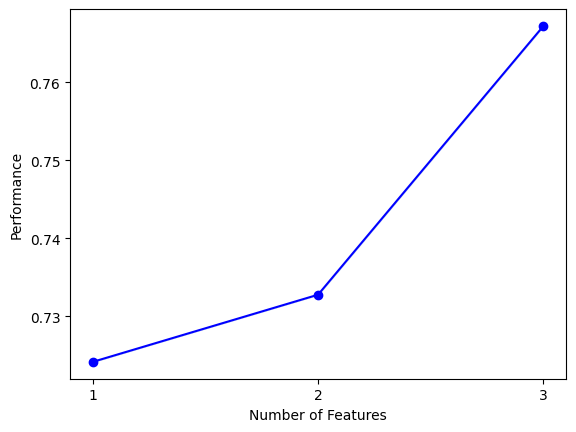

In [5]:
print(sfs.subsets_)

# Printing a subset of the names of the tuples selected alt
print(sfs.subsets_[3]["feature_names"])

#Printing the accuracy
print(f'Accuracy of the model {sfs.subsets_[3]["avg_score"]}')

# Plotting the accuracy 
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs 
plot_sfs(sfs.get_metric_dict())
plt.show()

<h1>Sequential Backward Selection</h1>

This works in the reverse to sequential forward selection - it starts with all features and removes one feature at a time. It will continue with the subset of features that perform best with the one feature removed and continue this sequentially. The algorithm stops at the number of desired features specified. 

In [6]:
# Implementing sequential backwards selection
sbs = SFS(model, k_features=3, forward=False, floating=False, scoring='accuracy', cv=0)
sbs.fit(X, y.values.ravel())

,estimator,LogisticRegre...max_iter=1000)
,k_features,"(3, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,0
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


<h2>Evaluating the result of Sequential Backwards Selection</h2>

{9: {'feature_idx': (0, 1, 2, 3, 4, 5, 6, 7, 8), 'cv_scores': array([0.80172414]), 'avg_score': 0.8017241379310345, 'feature_names': ('Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1')}, 8: {'feature_idx': (0, 1, 2, 3, 4, 5, 6, 7), 'cv_scores': array([0.80172414]), 'avg_score': 0.8017241379310345, 'feature_names': ('Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin')}, 7: {'feature_idx': (0, 1, 2, 3, 4, 5, 7), 'cv_scores': array([0.80172414]), 'avg_score': 0.8017241379310345, 'feature_names': ('Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Resistin')}, 6: {'feature_idx': (0, 1, 2, 3, 5, 7), 'cv_scores': array([0.80172414]), 'avg_score': 0.8017241379310345, 'feature_names': ('Age', 'BMI', 'Glucose', 'Insulin', 'Leptin', 'Resistin')}, 5: {'feature_idx': (0, 1, 2, 3, 7), 'cv_scores': array([0.79310345]), 'avg_score': 0.7931034482758621, 'feature_names': ('Age', 'BMI', 'Glucose', 'Insulin', 'Resistin')}, 4: {'featur

C:\Users\jai.trehan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlxtend\feature_selection\sequential_feature_selector.py:895: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  std_err = scipy.stats.sem(ary)


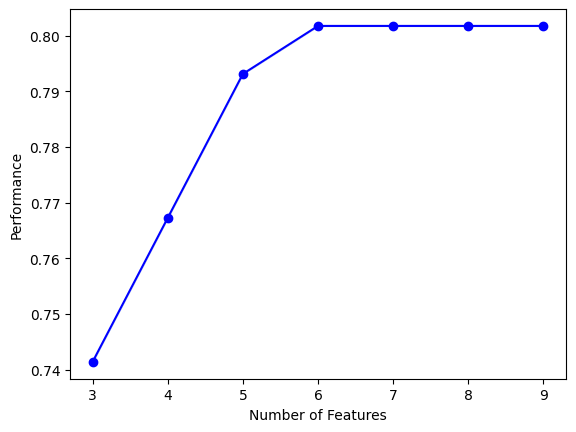

In [7]:
print(sbs.subsets_)

# Printing a subset of the names of the tuples selected alt
print(sbs.subsets_[3]["feature_names"])

#Printing the accuracy
print(f'Accuracy of the model {sbs.subsets_[3]["avg_score"]}')

# Plotting the accuracy 
plot_sfs(sbs.get_metric_dict())
plt.show()

<h1>Sequential Forward and Backward Floating Selection</h1> 

**Sequential Forward Floating Selection**, starts with zero features and adds one at a time. At each addition it also checks if any features can be removed. If performance <b>cannot</b> be improved another feature will be added.  If performance can be improved a feature is removed to increase performance the most. It will not permit infinite loops.

**Sequential Backward Floating Selection** starts with all features and removes one at a time. At each removal it also checks is any features can be added to improve model performance

In [10]:
# Implementation sequential forward floating selection 
sffs = SFS(model, k_features=3, forward=True, floating=True, scoring='accuracy', cv=0)
sffs.fit(X, y.values.ravel())
print(f"Chosen features using SFFS: {sffs.subsets_[3]['feature_names']}")

# Implementation sequential backward floating selection
sbfs = SFS(model, k_features=3, forward=False, floating=True, scoring='accuracy', cv=0)
sbfs.fit(X, y.values.ravel())
print(f"Features chosen by SBFS: {sbfs.subsets_[3]['feature_names']}")

Chosen features using SFFS: ('Age', 'Glucose', 'Insulin')
Features chosen by SBFS: ('Age', 'Glucose', 'Resistin')


<h1>Recursive Feature Elimination</h1>
